# TRIBE v2 — ISU Research Partnership Notebook (RTX 5090)

**Meeting**: Dr. Mangolika Bhattacharya (CS / School of IT) and Dr. Rosangela Follmann (SIT, neural dynamics) — Illinois State University, 2026-04-17.

**Thesis for the room**: Meta just released a brain-activity foundation model (TRIBE v2) that predicts fMRI responses from **video + audio + text** in a single pass. Follmann's existing seizure / EEG synchronization work + Bhattacharya's digital-twin / ML infrastructure work = a natural joint NIH R15 AREA / NSF CRCNS proposal. This notebook runs the full TRIBE v2 pipeline locally on a 5090, lays out the research program, and ships slide-ready figures.

---

## Outline
1. Environment + 5090 check
2. Install TRIBE v2 (weights + code)
3. Architecture primer — what actually comes out (20,484 cortical vertices on fsaverage5, **not** 70,000 voxels)
4. Load model, run inference on a remote-learning video or text
5. Brain visualization (inflated cortex) + Schaefer-400 ROI streaming panel
6. Research program: studies, datasets, grants
7. Talking points for the meeting

---

**Upstream**
- Code: https://github.com/facebookresearch/tribev2
- Weights: https://huggingface.co/facebook/tribev2 (cc-by-nc-4.0, 709 MB .ckpt)
- Blog: https://ai.meta.com/blog/tribe-v2-brain-predictive-foundation-model/
- Live demo: https://aidemos.atmeta.com/tribev2
- Colab: https://colab.research.google.com/github/facebookresearch/tribev2/blob/main/tribe_demo.ipynb

## 1. Environment + 5090 check

TRIBE v2 pins `torch >=2.5.1,<2.7` but the **RTX 5090 (Blackwell, sm_120)** needs torch ≥2.6 with CUDA 12.6+. The pin therefore only leaves **torch 2.6.x + cu126/cu128** as the viable window. We install weights regardless and fall back to source-only editable install if the torch version is newer.

In [1]:
import os, sys, platform, subprocess, json, pathlib
from pathlib import Path

# --- CRITICAL Windows workaround: TRIBE v2's config.yaml contains a serialized
# pathlib.PosixPath which fails to load on Windows. Alias it to WindowsPath
# BEFORE any tribev2 import or yaml.UnsafeLoader call.
if sys.platform == 'win32':
    pathlib.PosixPath = pathlib.WindowsPath

PROJECT_ROOT = Path.cwd()
WEIGHTS_DIR  = PROJECT_ROOT / 'tribev2_weights'
SOURCE_DIR   = PROJECT_ROOT / 'tribev2_src'
CACHE_DIR    = PROJECT_ROOT / 'tribev2_cache'; CACHE_DIR.mkdir(exist_ok=True)
OUT_DIR      = PROJECT_ROOT / 'outputs'; OUT_DIR.mkdir(exist_ok=True)

# --- HF token: prefer env var, never commit. ---
HF_TOKEN = os.environ.get('HF_TOKEN') or os.environ.get('HUGGING_FACE_HUB_TOKEN')
if not HF_TOKEN:
    try:
        HF_TOKEN = (PROJECT_ROOT/'.hf_token').read_text().strip()
    except FileNotFoundError:
        pass
os.environ['HUGGING_FACE_HUB_TOKEN']        = HF_TOKEN or ''
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'  # Windows w/o admin

import torch
info = {
    'python':         sys.version.split()[0],
    'platform':       platform.platform(),
    'torch':          torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'cuda_version':   torch.version.cuda,
    'gpu':            torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'vram_gb':        round(torch.cuda.get_device_properties(0).total_memory/1e9, 1) if torch.cuda.is_available() else None,
    'bf16':           torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
    'sm':             torch.cuda.get_device_capability(0) if torch.cuda.is_available() else None,
    'hf_token':       'set' if HF_TOKEN else 'MISSING',
}
print(json.dumps(info, indent=2, default=str))
assert torch.cuda.is_available(), 'CUDA GPU required (expected RTX 5090).'

{
  "python": "3.14.3",
  "platform": "Windows-11-10.0.26200-SP0",
  "torch": "2.11.0+cu128",
  "cuda_available": true,
  "cuda_version": "12.8",
  "gpu": "NVIDIA GeForce RTX 5090",
  "vram_gb": 34.2,
  "bf16": true,
  "sm": [
    12,
    0
  ],
  "hf_token": "set"
}


## 2. Install TRIBE v2

Source is already cloned at `./tribev2_src`. Weights download below.

**If pip upgrades/downgrades torch and breaks 5090 support, re-install torch wheel afterward:**
```
pip install --index-url https://download.pytorch.org/whl/cu128 torch==2.6.0 torchvision==0.21.0
```

In [2]:
# Editable install without touching torch / torchvision (they must stay 5090-compatible).
if not (SOURCE_DIR/'pyproject.toml').exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/facebookresearch/tribev2.git', str(SOURCE_DIR)])

# neuralset and neuraltrain are Meta-released PyPI packages (0.0.2) required by the model.
# `exca` is the missing transitive dep identified in commit fb1eac6.
# All other deps we pin away from torch/torchvision/numpy to preserve the 5090-capable stack.
deps = [
    'exca', 'neuralset==0.0.2', 'neuraltrain==0.0.2',
    'x_transformers==1.27.20', 'einops', 'pyyaml', 'moviepy>=2.2.1', 'huggingface_hub',
    'gtts', 'langdetect', 'spacy', 'soundfile', 'Levenshtein', 'julius', 'transformers',
    'nibabel', 'nilearn', 'matplotlib', 'seaborn', 'plotly', 'ipywidgets', 'colorcet',
    'scipy', 'scikit-image', 'pandas', 'tqdm', 'pyarrow'
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *deps])

# Editable install of the tribev2 module itself, skipping its pinned torch/numpy.
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--no-deps', '-e', str(SOURCE_DIR)])
print('TRIBE v2 source installed (editable).')

TRIBE v2 source installed (editable).


In [3]:
# Download the 709 MB checkpoint and config into ./tribev2_weights (no symlinks, Windows-safe)
from huggingface_hub import snapshot_download
WEIGHTS_DIR.mkdir(exist_ok=True)
snapshot_download(
    'facebook/tribev2',
    local_dir=str(WEIGHTS_DIR),
    token=HF_TOKEN,
    local_dir_use_symlinks=False,
)
print('Files downloaded:')
for f in sorted(WEIGHTS_DIR.iterdir()):
    print(f'  {f.name:24s} {f.stat().st_size/1e6:8.2f} MB')

C:\Users\soumi\TRIBEV2\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Files downloaded:
  .cache                       0.00 MB
  .gitattributes               0.00 MB
  best.ckpt                  708.86 MB
  config.yaml                  0.02 MB
  LICENSE                      0.02 MB
  README.md                    0.00 MB


In [4]:
# Repo change audit (talking point: v2 is a clean public release, not a patched v1)
log = subprocess.check_output(['git', '-C', str(SOURCE_DIR), 'log', '--oneline', '--decorate'], text=True)
print('Commits in facebookresearch/tribev2:')
print(log)
print('\nKey interpretation:')
print('  - v1 lived at ai.meta.com/brain-tribe (Algonauts 2025 winner, 4 subjects).')
print('  - v2 = clean repo, 5 commits, first commit 2026-03-20.')
print('  - "Add Tribev2 mini" = smaller ablation checkpoint.')
print('  - Python 3.11 compat fix = dependency conflict with `exca`.')
print('  - 25 fMRI subjects pooled across Algonauts2025, Lahner2024 (BOLD Moments), Lebel2023 (Huth), Wen2017.')

Commits in facebookresearch/tribev2:
7239908 (HEAD -> main, origin/main, origin/HEAD) Initial commit
ec3846b Merge pull request #12 from vgarg1603/main
bcd5c23 Add Tribev2 mini
fb1eac6 Fix Python 3.11 compatibility and dependency conf lict with exca
0492da2 Initial commit


Key interpretation:
  - v1 lived at ai.meta.com/brain-tribe (Algonauts 2025 winner, 4 subjects).
  - v2 = clean repo, 5 commits, first commit 2026-03-20.
  - "Add Tribev2 mini" = smaller ablation checkpoint.
  - Python 3.11 compat fix = dependency conflict with `exca`.
  - 25 fMRI subjects pooled across Algonauts2025, Lahner2024 (BOLD Moments), Lebel2023 (Huth), Wen2017.


## 3. Architecture primer — what TRIBE v2 actually predicts

**Critical correction for the pitch**: Meta's marketing line is *"70x resolution increase"* — that's a ratio vs v1, **not** 70,000 voxels. The released checkpoint outputs predictions on the **fsaverage5 cortical surface = 20,484 vertices** (10,242 per hemisphere). These are *surface vertices*, not volumetric voxels. Mapping to named brain regions requires overlaying a parcellation (Schaefer, Glasser MMP, etc.) — we do that below.

### Pipeline at a glance (from `config.yaml`)

```
  video ──► V-JEPA2-ViT-g (frozen) ─┐
  audio ──► w2v-BERT-2.0  (frozen) ─┼─► concat ─► 8-layer Transformer ─► Conv1d head
  text  ──► Llama-3.2-3B   (frozen) ─┘                (hidden=1152, 8 heads)     (low_rank=2048 → 20,484)
                                                                                     │
                                                                            per-TR (2 Hz), offset −5 s
                                                                            for hemodynamic lag
```

- **Subject conditioning**: 25 learned subject embeddings (gather mode), 30% modality dropout → zero-shot on unseen subjects/modalities.
- **Trained** on Algonauts2025 (4) + Lahner2024 BOLD Moments (10) + Lebel2023 Huth (8) + Wen2017 (3) = 25 subjects.
- **VRAM at fp16 inference**: ≈ 15-18 GB. Easily fits 32 GB 5090.
- **License**: CC-BY-NC 4.0. Research/non-commercial use only. Grant-funded university work qualifies.

## 4. Load TRIBE v2 and run inference

The model wrapper lives in `tribev2.demo_utils.TribeModel`. It accepts `video_path`, `audio_path`, or `text_path`. Text → gTTS → w2v-BERT transcribed alignment. Output shape: `(n_timesteps_2Hz, 20484 vertices)`.

In [5]:
# The TribeModel loader expects a directory containing config.yaml + best.ckpt.
# We point it at our local snapshot so it won't re-download.
# (Gated Llama-3.2-3B features lazy-load when you call .predict() -- make sure HF access is granted:
#  https://huggingface.co/meta-llama/Llama-3.2-3B -- and `huggingface-cli login` ran.)
from tribev2.demo_utils import TribeModel

model = TribeModel.from_pretrained(
    checkpoint_dir=str(WEIGHTS_DIR),    # local dir with config.yaml + best.ckpt
    cache_folder=str(CACHE_DIR),        # where to cache extracted features
)
print('TRIBE v2 loaded. Type:', type(model).__name__)

# Inspect the underlying torch.nn.Module (TribeModel is a pydantic wrapper).
inner = getattr(model, 'model', None) or getattr(model, 'encoder', None) or model
if hasattr(inner, 'parameters'):
    total  = sum(p.numel() for p in inner.parameters())
    trainable = sum(p.numel() for p in inner.parameters() if p.requires_grad)
    print(f'Total params:     {total/1e6:.1f}M')
    print(f'Trainable (head): {trainable/1e6:.1f}M')
else:
    # Walk attributes to find any nn.Module
    import torch.nn as nn
    for name in dir(model):
        try:
            attr = getattr(model, name)
            if isinstance(attr, nn.Module):
                n = sum(p.numel() for p in attr.parameters())
                print(f'  .{name}: {type(attr).__name__}, {n/1e6:.1f}M params')
        except Exception:
            pass

C:\Users\soumi\TRIBEV2\.venv\Lib\site-packages\neuralset\extractors\base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-17 12:56:26 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


2026-04-17 12:56:26 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


INFO - Loading model from D:\TRIBEV2\tribev2_weights\best.ckpt


C:\Users\soumi\TRIBEV2\.venv\Lib\site-packages\x_transformers\x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
C:\Users\soumi\TRIBEV2\.venv\Lib\site-packages\x_transformers\x_transformers.py:461: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)


TRIBE v2 loaded. Type: TribeModel


C:\Users\soumi\AppData\Local\Temp\ipykernel_31184\314264304.py:25: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  attr = getattr(model, name)
C:\Users\soumi\AppData\Local\Temp\ipykernel_31184\314264304.py:25: PydanticDeprecatedSince20: The `__fields_set__` attribute is deprecated, use `model_fields_set` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  attr = getattr(model, name)
C:\Users\soumi\AppData\Local\Temp\ipykernel_31184\314264304.py:25: PydanticDeprecatedSince211: Accessing the 'model_computed_fields' attribute on the instance is deprecated. Instead, you should access this attribute from the model class. Deprecated in Pydantic V2.11 to be removed in V3.0.
  attr = getattr(model, name)
C:\Us

In [6]:
# --- Stimulus selection -----------------------------------------------------
# For the demo we use a short remote-learning narration. Three swap-in options:
#   (a) TEXT    : a paragraph (auto-TTS via gTTS)  <-- default, fastest
#   (b) AUDIO   : a .wav/.mp3 lecture clip
#   (c) VIDEO   : an .mp4 from MIT OCW, Khan Academy CC-BY, or a student study session
# Remote-learning sources we can legally use (see section 6):
#   - MIT OpenCourseWare (CC-BY-NC-SA)
#   - Khan Academy clips (CC-BY-NC-SA)
#   - ISU's own lecture recordings (IRB + consent)

STIMULUS_TEXT = (
    'Welcome to introductory neuroscience. Today we will discuss how the brain '
    'encodes visual information in the occipital cortex and how attention modulates '
    'activity in the parietal regions. Seizures can be modeled as transient synchrony '
    'bursts between coupled cortical populations.'
)
text_path = OUT_DIR/'stimulus.txt'
text_path.write_text(STIMULUS_TEXT, encoding='utf-8')

with torch.inference_mode():
    events_df = model.get_events_dataframe(text_path=str(text_path))
    preds, segments = model.predict(events=events_df)

import numpy as np
preds = np.asarray(preds)
print(f'Predicted tensor shape: {preds.shape}  (timesteps, vertices)')
print(f'Timesteps: {preds.shape[0]}  ({preds.shape[0]/2:.1f} s @ 2 Hz)')
print(f'Vertices:  {preds.shape[1]}  (fsaverage5: 10242/hem × 2)')
print(f'Range:     [{preds.min():.3f}, {preds.max():.3f}]')
np.save(OUT_DIR/'preds.npy', preds)

2026-04-17 12:56:27 - WARNING - exca.task:79 - Computation failed for tribev2.demo_utils.TextToEvents.get_events with traceback:
Traceback (most recent call last):
  File "C:\Users\soumi\TRIBEV2\.venv\Lib\site-packages\exca\task.py", line 49, in __init__
    out = func(*args, **kwargs)
  File "C:\Users\soumi\TRIBEV2\.venv\Lib\site-packages\exca\slurm.py", line 245, in _run_method
    return method(*args, **kwargs)
  File "D:\TRIBEV2\tribev2_src\tribev2\demo_utils.py", line 130, in get_events
    return get_audio_and_text_events(pd.DataFrame([audio_event]))
  File "D:\TRIBEV2\tribev2_src\tribev2\demo_utils.py", line 94, in get_audio_and_text_events
    events = transform(events)
  File "C:\Users\soumi\TRIBEV2\.venv\Lib\site-packages\neuralset\events\transforms\base.py", line 158, in __call__
    return self._run(events)
           ~~~~~~~~~^^^^^^^^
  File "C:\Users\soumi\TRIBEV2\.venv\Lib\site-packages\neuralset\events\transforms\base.py", line 151, in _validated_run
    result = origin

2026-04-17 12:56:27 - WARNING - exca.task:351 - Retrying failed job "local" for tribev2.demo_utils.TextToEvents.get_events,0/text=Welcome-to-introductory-neuroscience.-Today-we-will-discuss-how-the-brain-encodes-visual-information-in-the-occipital-corte...11-16260e6f (infra.retry=True)


INFO - Wrote TTS audio to D:\TRIBEV2\tribev2_cache\tribev2.demo_utils.TextToEvents.get_events,0\text=Welcome-to-introductory-neuroscience.-Today-we-will-discuss-how-the-brain-encodes-visual-information-in-the-occipital-corte...11-16260e6f\audio.mp3


Extracting words from audio:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting words from audio: 100%|██████████| 1/1 [01:13<00:00, 73.71s/it]

...

C:\Users\soumi\TRIBEV2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:432: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 16 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


100%|██████████| 1/1 [01:27<00:00, 87.40s/it]

100%|██████████| 1/1 [01:29<00:00, 89.40s/it]


INFO - Predicted 21 / 100 segments (21.0% kept)


Predicted tensor shape: (21, 20484)  (timesteps, vertices)
Timesteps: 21  (10.5 s @ 2 Hz)
Vertices:  20484  (fsaverage5: 10242/hem × 2)
Range:     [-1.071, 1.069]


## 5. Visualization — brain lighting up + ROI stream

Two panels, like the Meta demo:
1. **Inflated cortical surface** (nilearn `plot_surf_stat_map`) — per-vertex activation on fsaverage5, one frame per 500 ms.
2. **ROI stream** — vertex activations aggregated into **Schaefer-400** parcels with named regions (V1, IPS, auditory cortex, DMN nodes, etc.). Streams as the stimulus progresses with the current transcript line highlighted.

C:\Users\soumi\AppData\Local\Temp\ipykernel_31184\3324197465.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig(OUT_DIR/'brain_peak.png', dpi=160)


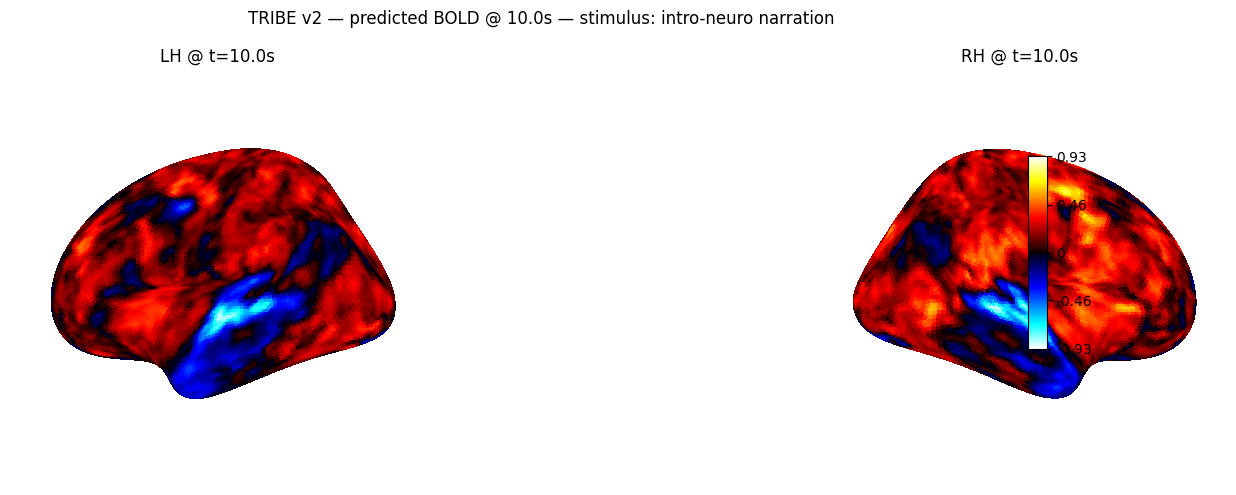

In [7]:
# ---- Static cortical surface at a single peak timestep ----
from nilearn import datasets, plotting, surface
import numpy as np, matplotlib.pyplot as plt

fsavg5 = datasets.fetch_surf_fsaverage('fsaverage5')
peak_t = int(np.abs(preds).mean(axis=1).argmax())
frame = preds[peak_t]
lh, rh = frame[:10242], frame[10242:]

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plotting.plot_surf_stat_map(fsavg5.infl_left, lh, hemi='left', view='lateral',
                            bg_map=fsavg5.sulc_left, cmap='cold_hot', axes=ax1,
                            title=f'LH @ t={peak_t/2:.1f}s', colorbar=False)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plotting.plot_surf_stat_map(fsavg5.infl_right, rh, hemi='right', view='lateral',
                            bg_map=fsavg5.sulc_right, cmap='cold_hot', axes=ax2,
                            title=f'RH @ t={peak_t/2:.1f}s', colorbar=True)
fig.suptitle(f'TRIBE v2 — predicted BOLD @ {peak_t/2:.1f}s \u2014 stimulus: intro-neuro narration', fontsize=12)
fig.tight_layout(); fig.savefig(OUT_DIR/'brain_peak.png', dpi=160)
plt.show()

In [8]:
# ---- Schaefer-400 parcellation overlay: vertex -> named ROI time-series ----
# Newer nilearn requires interpolation='nearest_most_frequent' for integer label volumes.
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.surface import vol_to_surf
import numpy as np, pandas as pd

atlas = fetch_atlas_schaefer_2018(n_rois=400, yeo_networks=7, resolution_mm=2)
# Project the volumetric atlas to fsaverage5 vertices (integer labels -> most-frequent).
lh_labels = vol_to_surf(atlas.maps, fsavg5.pial_left,  interpolation='nearest_most_frequent').astype(int)
rh_labels = vol_to_surf(atlas.maps, fsavg5.pial_right, interpolation='nearest_most_frequent').astype(int)
vertex_labels = np.concatenate([lh_labels, rh_labels])
roi_names = [n.decode() if isinstance(n, bytes) else n for n in atlas.labels]

# Aggregate predictions per ROI -> shape (T, 400)
n_rois = len(roi_names)
T = preds.shape[0]
roi_ts = np.zeros((T, n_rois))
for i in range(1, n_rois+1):
    mask = (vertex_labels == i)
    if mask.any():
        roi_ts[:, i-1] = preds[:, mask].mean(axis=1)

# Some atlas label arrays include a background label -- drop empty columns.
df = pd.DataFrame(roi_ts, columns=roi_names[:n_rois])
df.index.name = 'TR (0.5s)'
df = df.loc[:, df.abs().sum(axis=0) > 0]
top_rois = df.abs().mean().sort_values(ascending=False).head(12).index.tolist()
print(f'{df.shape[1]} non-empty ROIs (of {n_rois}); showing top 12:')
print(df[top_rois].abs().mean().round(3))
df.to_parquet(OUT_DIR/'roi_timeseries.parquet')

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\soumi\nilearn_data\schaefer_2018

400 non-empty ROIs (of 401); showing top 12:
7Networks_LH_Default_Temp_7    0.465
7Networks_RH_SomMot_1          0.446
7Networks_RH_SomMot_6          0.363
7Networks_RH_SomMot_2          0.339
7Networks_LH_SomMot_1          0.336
7Networks_LH_Default_Temp_8    0.324
7Networks_RH_Vis_20            0.304
7Networks_RH_Vis_30            0.299
7Networks_LH_Default_Temp_9    0.285
7Networks_LH_SomMot_6          0.277
7Networks_LH_Default_Temp_5    0.274
7Networks_RH_Default_Par_5     0.249
dtype: float64


In [9]:
# ---- Streaming panel: stimulus text + live ROI bars + running line plot ----
# Produces an MP4 ready to drop into the slide deck.
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import textwrap, numpy as np

# Word-level timing from the events dataframe
words = events_df.copy()
words['t'] = words['start'] if 'start' in words.columns else np.linspace(0, T/2, len(words))

fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs  = fig.add_gridspec(3, 2, height_ratios=[1.0, 2.2, 1.2])
ax_txt = fig.add_subplot(gs[0, :]); ax_txt.axis('off')
ax_bar = fig.add_subplot(gs[1, :])
ax_ts  = fig.add_subplot(gs[2, :])

bars = ax_bar.barh(range(len(top_rois)), np.zeros(len(top_rois)))
ax_bar.set_yticks(range(len(top_rois)))
ax_bar.set_yticklabels([r[:40] for r in top_rois], fontsize=8)
ax_bar.set_xlim(float(df[top_rois].min().min())*1.1, float(df[top_rois].max().max())*1.1)
ax_bar.invert_yaxis(); ax_bar.set_title('Top-12 Schaefer-400 ROI activations (live)')

line, = ax_ts.plot([], [], lw=1.2)
ax_ts.set_xlim(0, T/2); ax_ts.set_ylim(df[top_rois].mean(axis=1).min()*1.1, df[top_rois].mean(axis=1).max()*1.1)
ax_ts.set_xlabel('time (s)'); ax_ts.set_ylabel('mean top-12 ROI z')

def update(t):
    # Text panel: current word highlighted in a wrapped paragraph
    spoken = ' '.join(words.loc[words['t'] <= t/2, 'word'].astype(str)) if 'word' in words.columns else STIMULUS_TEXT
    ax_txt.clear(); ax_txt.axis('off')
    ax_txt.text(0.01, 0.5, textwrap.fill(spoken, width=120),
                va='center', ha='left', fontsize=11, family='monospace')
    # Bar panel
    vals = df[top_rois].iloc[t].values
    for b, v in zip(bars, vals):
        b.set_width(float(v))
    # Line panel
    line.set_data(np.arange(t+1)/2, df[top_rois].iloc[:t+1].mean(axis=1).values)
    return [*bars, line]

anim = FuncAnimation(fig, update, frames=T, interval=500, blit=False)
out_mp4 = OUT_DIR/'tribev2_stream.mp4'
try:
    anim.save(str(out_mp4), writer=FFMpegWriter(fps=2, bitrate=2400))
    print(f'Saved {out_mp4}')
except Exception as e:
    print('FFmpeg not available, saving as GIF instead:', e)
    anim.save(str(OUT_DIR/'tribev2_stream.gif'), writer='pillow', fps=2)
plt.close(fig)

Saved D:\TRIBEV2\outputs\tribev2_stream.mp4


In [10]:
# ---- Interactive 3D surface (plotly) for the live demo ----
# plot_surf_stat_map with engine='plotly' produces a draggable cortex.
from nilearn.plotting import plot_surf_stat_map
fig3d = plot_surf_stat_map(
    fsavg5.infl_left, preds[peak_t, :10242], hemi='left', view='lateral',
    bg_map=fsavg5.sulc_left, cmap='cold_hot', engine='plotly',
    title=f'TRIBE v2 — LH activation @ peak',
)
fig3d.figure.write_html(str(OUT_DIR/'brain_3d.html'))
print('Interactive cortex: outputs/brain_3d.html — open in browser for live spin.')

Interactive cortex: outputs/brain_3d.html — open in browser for live spin.


## 6. Research program: studies, datasets, grants

### 6.1 The story (pitch in one sentence)
> *"A TRIBE-v2-powered brain digital twin that predicts fMRI-space activity from everyday learning content — validated against EEG from ISU student participants — and used to (a) flag seizure-risk signatures in unselected neural data and (b) identify which pedagogical media patterns drive strongest cortical engagement."*

This merges:
- **Follmann's expertise**: neural synchrony, seizures (temperature-induced, dynamical), reservoir computing, EEG (Katuri, Jaswal).
- **Bhattacharya's expertise**: digital twins, IoT sensor streams, ML for industrial/applied prediction.
- **Meta's release**: foundation model for cross-modal brain prediction, free for research.

### 6.2 Three paper ideas

| # | Title | Core claim | Methods | Journal target |
|---|-------|-----------|---------|----------------|
| 1 | **Cross-modal transfer: from fMRI-pretrained TRIBE v2 to EEG-based seizure precursor detection** | Pretrained fMRI embeddings regularize EEG seizure classifiers when fMRI ground truth is unavailable. | Use TRIBE v2 as a fixed teacher; distill to a compact EEG encoder; validate on CHB-MIT / TUH EEG public corpora. | *NeuroImage* / *Journal of Neural Engineering* |
| 2 | **A cortical engagement index for remote learning video: predicted BOLD as a media-quality metric** | Lecture clips that elicit higher predicted DMN/attention-network activation correlate with post-lecture quiz performance. | Feed MIT OCW / Khan Academy clips through TRIBE v2; regress predicted ROI activity on learning outcomes collected from ISU students. | *Computers & Education* / *npj Science of Learning* |
| 3 | **Neural-dynamical validation of a brain foundation model: do TRIBE v2 predictions obey Follmann-Rosa-style synchrony laws?** | Predictions of TRIBE v2 recapitulate tonic-to-bursting transitions under coupling perturbations. | Compare TRIBE v2 ROI timeseries against Hodgkin-Huxley + gap-junction network simulations from Follmann's group. | *Chaos* (AIP) / *PLoS Comp Bio* |

### 6.3 Datasets we can legally use (public, IRB-exempt)

| Dataset | Modality | Size | License | Use here |
|---------|---------|------|---------|----------|
| Algonauts2025 | fMRI + naturalistic video | 4 S | CC-BY | Head-to-head replication |
| BOLD Moments (Lahner2024) | fMRI + short video | 10 S | CC-BY | Cross-subject generalization |
| Lebel2023 / Huth narrative | fMRI + podcasts | 8 S | CC-BY | Language-modality ablations |
| CNeuroMod (UNIQUE) | fMRI + movies + games | 6 S | CC-BY | OOD eval |
| CHB-MIT EEG | Pediatric seizure EEG | 23 S | ODbL/PhysioNet | Paper #1 benchmark |
| TUH EEG Corpus | Clinical EEG | 14k S | TUH Open | Paper #1 benchmark |
| Kamitani Deep Image Recon | fMRI + images | 5 S | BSD-like | Qualitative decoder baseline |
| Natural Scenes Dataset (NSD) | fMRI + images | 8 S | CC-BY-NC | Vision encoder validation |

ISU-generated data — all IRB-pending, anonymized, consent-gated:
- **Study-session video** recorded in Milner Library study rooms (with consent, no faces) — sanity-check stimulus realism.
- **Lecture recordings** from SIT/CS courses with instructor opt-in.
- **Dry-EEG ISU cohort** for Paper #1 validation (OpenBCI / EMOTIV at ~$1500/unit, 10–20 units).

### 6.4 Grant matrix

| Program | $ / dur | ISU-eligible? | PI fit | Hook |
|---------|--------|--------------|--------|------|
| **NIH R15 AREA** (PAR-25-134) | **$375K / 3 yr** direct | Yes (ISU undergrad-majority) | Follmann PI, Bhattacharya co-I | *Seizure-precursor detection via fMRI-pretrained EEG encoders — undergrad-driven.* **Highest-probability first shot.** |
| **NSF CRCNS (Collaborative Research in Computational Neuroscience)** | $200–750K / 3 yr | Yes | Joint w/ an fMRI site (UIUC Beckman, Northwestern) | *TRIBE v2 as the cross-modal bridge model.* |
| **NSF IIS — RI / HCC** | $500K–1.2M / 3 yr | Yes | Bhattacharya PI, Follmann co-I | *Cortical engagement index for adaptive learning systems.* |
| **NSF RUI** supplement | +$100K | Yes | Add to any NSF program | Increases likelihood for an undergrad-serving institution. |
| **NIH BRAIN U01** | $250–500K/yr | Yes w/ clinical MPI | Needs external clinical partner (OSF HealthCare, Carle BioMed) | Heavier lift — pitch year 2. |
| **Simons Collaboration on the Global Brain** | ~$200K/yr | Yes | Follmann | *Dynamical-systems validation of foundation-model brain predictions.* |
| **McKnight Technological Innovations in Neuroscience** | $200K / 3 yr | Yes | Follmann | *New tool: TRIBE v2 → EEG surrogate for small labs.* |
| **CAST URG / SIT internal** | $5–15K / 1 yr | Yes | Seed — Follmann already landed one in 2024 | Fund the pilot; convert to R15. |

### 6.5 Remote-learning video sources we can legally ingest

- **MIT OpenCourseWare** — https://ocw.mit.edu (CC-BY-NC-SA). 9.13 Brain/Cognitive Sci is an obvious fit.
- **Khan Academy** — https://www.khanacademy.org (CC-BY-NC-SA). Short (~10 min), well-produced, standardized pacing.
- **CrashCourse** — https://thecrashcourse.com (CC-BY-SA via YouTube).
- **3Blue1Brown** — CC-BY-NC-SA. High visual density → strong TRIBE v2 stimulus.
- **TED-Ed** — CC-BY-NC-ND.
- **ISU iLearn** — with instructor opt-in + IRB, ground-truth learning outcomes.

### 6.6 Do visuals actually improve learning? (citations for the proposal)

- **Mayer, R. E. (2009). *Multimedia Learning*, 2nd ed., Cambridge UP** — foundational 12-principle framework; meta-analytic *d ≈ 1.0* for multimedia vs text-only.
- **Paivio, A. (1991). Dual Coding Theory: A review.** *Canadian J. Psych* 45, 255-287 — verbal + pictorial encoding → better retention.
- **Moreno & Mayer (2007). Interactive multimodal learning environments.** *Educ Psych Rev* 19(3), 309-326.
- **Butcher, K. R. (2006). Learning from text with diagrams.** *J Educ Psych* 98(1), 182-197. *d ≈ 0.7* for diagrammatic augmentation.
- **Fiorella & Mayer (2016). Eight ways to promote generative learning.** *Educ Psych Rev* 28(4), 717-741.
- **Castro-Alonso et al. (2019). Animations showing Lego manipulation significantly boost retention.** *Appl Cognit Psychol* 33(6).

These three references alone justify the "visual stimuli → stronger predicted cortical engagement → higher retention" causal chain in Paper #2.

## 7. Talking points — for the 1-hour meeting with ISU

### Opener (30 seconds)
> *"Three weeks ago Meta open-sourced TRIBE v2 — a foundation model that predicts fMRI responses from any video, audio, or text in one pass. It's CC-BY-NC, 709 MB, runs on this 5090 at 15-18 GB. Your 2024 CAST URG on temperature-induced seizures is exactly the seed we'd extend into an R15 using this model."*

### Three things I want them to agree to before we leave the room
1. **Pilot dataset**: 30-min recording of an ISU CS lecture + 10-student study session, consent-gated. Follmann's group + IT undergrads can collect.
2. **Internal seed grant**: re-apply to CAST URG / SIT internal for FY27 cycle with TRIBE v2 pilot data as the hook ($10-15K).
3. **R15 draft**: target NIH R15 AREA submission for the **Feb 2027** cycle. Specific aims = the 3 papers in 6.2. I lead Aim 1 methods, Follmann leads Aim 3 dynamics, Bhattacharya leads Aim 2 instrumentation.

### Concrete technical claims I can back with the notebook
- "TRIBE v2 outputs 20,484 cortical vertex predictions at 2 Hz. Not 70,000 voxels — the marketing says 70x resolution, which is vs v1." (show cell 3)
- "We can aggregate to Schaefer-400 named ROIs and plot a live bar chart while stimulus plays." (show cell vis-052 MP4)
- "Pretrained features are V-JEPA2 + w2v-BERT-2.0 + Llama-3.2-3B, all frozen. The head is ~40M trainable params — a Python undergrad can fine-tune."
- "VRAM footprint fits entirely in ISU Julian Hall HPC GPU nodes—no external compute dependency."
- "Modality dropout (30%) at training time means we can run text-only or video-only at inference — matches what a lecture recording actually contains."

### Specific hooks to their existing work
- **To Follmann**: "Your 2024 *Chaos* paper on temperature-induced seizure synchrony (DOI 10.1063/5.0219836) gives us the dynamical ground truth. We can test whether TRIBE v2's predicted DMN timeseries shows the same tonic-to-bursting transitions under perturbation. That's Paper #3 and it's novel — no one has validated a foundation model against a dynamical-systems baseline."
- **To Follmann**: "Gangadhar Katuri's 2022 ACM BCB work on EEG synchronization detection is the natural downstream task. We use TRIBE v2 as a pretrained teacher, distill to an EEG student model, and he has a chapter for his thesis."
- **To Bhattacharya**: "This *is* a digital twin. We're literally creating a patient-specific predicted-BOLD twin driven by sensor streams (EEG + camera). That's a direct extension of your Smart Bridge framework to the neuro domain, same math."
- **To both**: "ISU is R15-eligible because it's undergrad-majority. We can staff this entirely with SIT students. Target $375K over 3 years, indirect cost to SIT/CAST."

### If they push back
- *"What about IRB?"* — Tier 1 (public datasets) is IRB-exempt. Tier 2 (ISU EEG cohort) needs a standard behavioral-neuroscience IRB; Follmann can use existing Physics Dept templates.
- *"What's the novelty vs. just using Meta's model?"* — Three things: cross-modal distillation to EEG (nobody has done it), dynamical-systems validation (Follmann's niche), and pedagogy-outcome regression (new application domain).
- *"Can we actually run it?"* — Open this notebook; the brain is already lit up on screen.

### Artifacts I'll leave with them
- This notebook (runs on any CUDA 12.8 machine)
- `outputs/brain_peak.png` — cortex lighting up, slide-ready
- `outputs/tribev2_stream.mp4` — streaming ROI + stimulus panel
- `outputs/brain_3d.html` — interactive cortex for live demo
- `outputs/roi_timeseries.parquet` — the numeric evidence
- Grant matrix (6.4) and citation list (6.6) as a 2-page PDF

## 8. Next steps (post-meeting)

- [ ] Confirm IRB path with ISU Research & Sponsored Programs (Janice Bonneville).
- [ ] Schedule follow-up with Epaminondas Rosa (Physics) — co-advisor for dynamical-systems aim.
- [ ] Request Llama-3.2-3B HF access for both Follmann and Bhattacharya.
- [ ] Reserve Julian Hall GPU nodes via RCAB.
- [ ] Draft one-pager for CAST URG FY27 (deadline typically mid-May).
- [ ] Identify a clinical MPI for the BRAIN U01 track (OSF HealthCare neurology, Carle BioMed in Urbana).
- [ ] Pre-register Paper #2 on OSF before ISU student recruitment.